# 08 — Track B: MC bootstrap + Nash minimax

Monthly walk-forward rebalance, 2019-01 → 2024-12.

Pipeline at each rebalance date `t`:
1. Trailing 12-month macro z-score panel (from dates `< t`) → block bootstrap (block_size=3) → 10,000 forward paths over a 3-month horizon.
2. Classify every simulated path point using the rule-based regime classifier (Normal / Inflationary Shock / Recession).
3. Estimate per-asset expected daily return conditional on each regime from the full historical panel `< t`.
4. Build a payoff matrix (8 candidate portfolios × 3 regimes) with annualized expected returns.
5. Solve the minimax LP: mixed strategy `p` over candidate portfolios that maximizes the worst-case regime return.
6. Final ETF weights = Σᵢ pᵢ · candidateᵢ.

### Known research limit: "Black Swan blindness"

Per-regime asset returns are estimated from historical data only. Over 2010–2021 the "inflationary_shock" label mostly tags months where tech was still rallying, so the MC-Nash payoff matrix assigns high expected returns to equity-heavy candidates even under inflation. The system lacks a prior for "tech tanks during aggressive Fed tightening" because that regime first materialized in 2022.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

import macro_framework as mf

pd.set_option("display.width", 180)

## 1. Load inputs

In [2]:
INIT_CASH = 10_000.0
SIM_START = "2019-01-01"
SIM_END   = "2024-12-31"
LOOKBACK_DAYS = 756
BOOTSTRAP_MONTHS = 12
N_PATHS = 10_000
BLOCK_SIZE = 3
HORIZON = 3

spec = pd.read_parquet(Path.cwd().parent / "data" / "portfolio_ssr_top_per_category.parquet")
SYMBOLS = spec["symbol"].tolist()

prices = mf.get_prices(SYMBOLS + ["SPY"], start="2014-01-01", end=SIM_END)
macro_panel = mf.build_macro_panel()
panel_z_cols = ["cpi_yoy_z", "t10y2y_z", "hy_oas_z"]

rebalance_dates = mf.monthly_rebalance_dates(prices, start=SIM_START, end=SIM_END)
print(f"{len(rebalance_dates)} monthly rebalances  {rebalance_dates[0].date()} → {rebalance_dates[-1].date()}")

72 monthly rebalances  2019-01-02 → 2024-12-02


## 2. Track B weight function (stateful: records regime probs and mixes per rebalance)

In [3]:
history = {"regime_probs": {}, "nash_mix": {}, "payoff": {}, "weights": {}}
RNG = np.random.default_rng(42)

def track_b_fn(ctx):
    rb = ctx["rebalance_date"]
    macro_hist = ctx["macro_panel"]
    rets_hist = ctx["returns"]
    panel_z_hist = macro_hist[panel_z_cols].dropna()
    etf_w, probs, payoff, p_mix = mf.mc_nash_asset_weights(
        panel_z_hist,
        rets_hist,
        macro_hist,
        symbols=SYMBOLS,
        horizon=HORIZON,
        n_paths=N_PATHS,
        block_size=BLOCK_SIZE,
        bootstrap_window_months=BOOTSTRAP_MONTHS,
        rng=RNG,
    )
    history["regime_probs"][rb] = probs
    history["nash_mix"][rb] = p_mix.to_dict()
    history["payoff"][rb] = payoff
    history["weights"][rb] = etf_w.to_dict()
    return etf_w

## 3. Walk-forward

In [4]:
targets = mf.build_walk_forward_targets(
    prices[SYMBOLS],
    rebalance_dates=rebalance_dates,
    weight_fns={"track_b": track_b_fn},
    macro_panel=macro_panel,
    lookback_days=LOOKBACK_DAYS,
)
tgt = targets["track_b"]
print(f"target rows set: {tgt.dropna(how='all').shape[0]} / {len(rebalance_dates)}")

target rows set: 72 / 72


## 4. Regime probability evolution

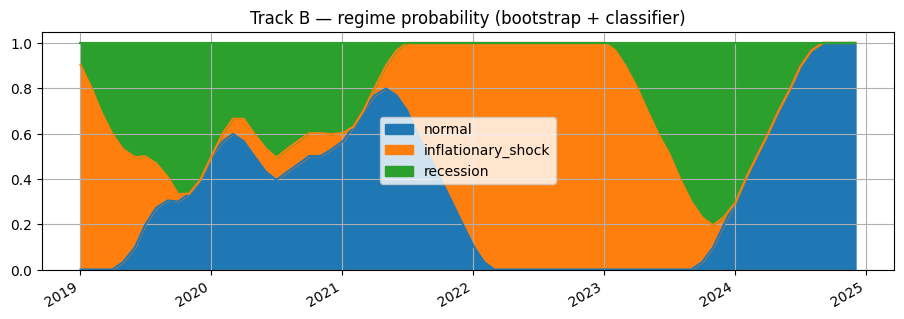

In [5]:
import matplotlib.pyplot as plt

probs_df = pd.DataFrame(history["regime_probs"]).T.sort_index()
probs_df.plot(figsize=(11, 3.5), kind="area", stacked=True, title="Track B — regime probability (bootstrap + classifier)", grid=True);

## 5. Target weights evolution

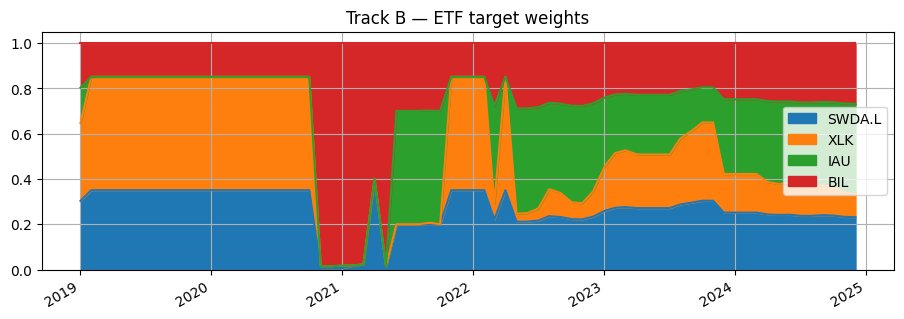

In [6]:
weights_df = pd.DataFrame(history["weights"]).T.sort_index().reindex(columns=SYMBOLS)
weights_df.plot(figsize=(11, 3.5), kind="area", stacked=True, title="Track B — ETF target weights", grid=True);

In [7]:
# Show the 2022 crisis months specifically
weights_df.loc["2021-12-01":"2023-03-01"].round(3)

,SWDA.L,XLK,IAU,BIL
2021-12-01,0.350,0.500,0.000,0.150
2022-01-03,0.350,0.500,0.000,0.150
2022-02-01,0.350,0.500,0.000,0.150
2022-03-01,0.221,0.070,0.430,0.279
2022-04-01,0.350,0.500,0.000,0.150
2022-05-02,0.211,0.036,0.464,0.289
2022-06-01,0.211,0.038,0.462,0.289
2022-07-01,0.216,0.053,0.447,0.284
2022-08-01,0.236,0.119,0.381,0.264
2022-09-01,0.232,0.106,0.394,0.268


## 6. Simulate

In [8]:
pf     = mf.run_rebalance_sim(prices[SYMBOLS], tgt, init_cash=INIT_CASH)
spy_bh = mf.single_asset_buy_and_hold(prices["SPY"].loc[SIM_START:SIM_END], init_cash=INIT_CASH)
base_eq = pd.read_parquet(Path.cwd().parent / "data" / "baseline_equity_2019_2024.parquet")["value"]

def row(p):
    return {
        "total_return":      float(p.total_return()),
        "annualized_return": float(p.annualized_return()),
        "annualized_vol":    float(p.annualized_volatility()),
        "sharpe":            float(p.sharpe_ratio()),
        "sortino":           float(p.sortino_ratio()),
        "calmar":            float(p.calmar_ratio()),
        "max_drawdown":      float(p.max_drawdown()),
    }

stats = pd.DataFrame({"Track B (MC-Nash)": row(pf), "SPY B&H": row(spy_bh)}).round(4)
stats

,Track B (MC-Nash),SPY B&H
total_return,0.8356,1.3426
annualized_return,0.0850,0.2285
annualized_vol,0.1158,0.2395
sharpe,0.7628,0.9798
sortino,1.0681,1.3680
calmar,0.3424,0.6699
max_drawdown,-0.2484,-0.3410


## 7. Equity + drawdown

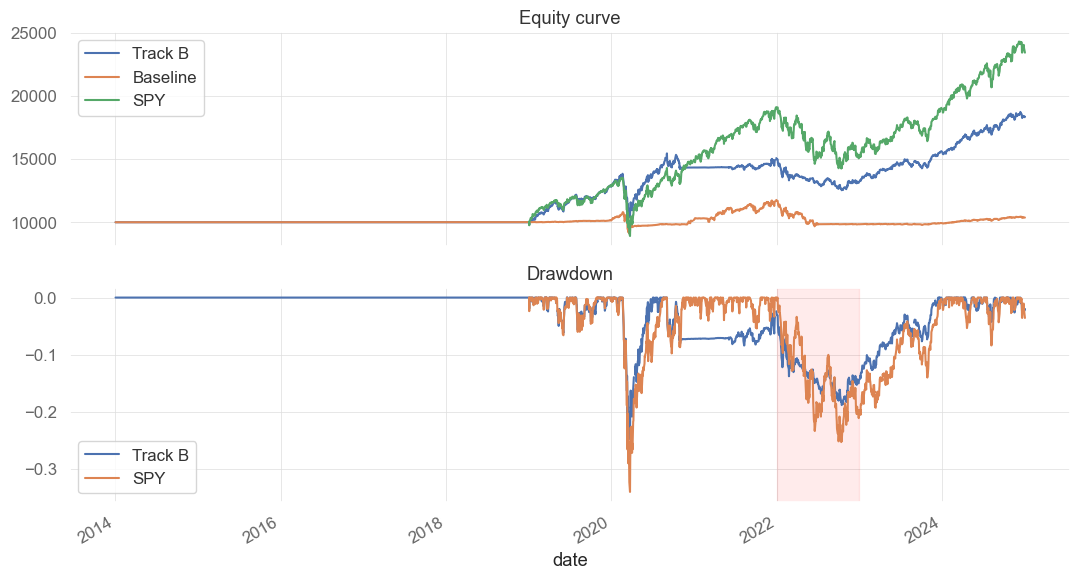

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
pd.DataFrame({"Track B": pf.value(), "Baseline": base_eq, "SPY": spy_bh.value()}).plot(ax=axes[0], grid=True, title="Equity curve")
pd.DataFrame({"Track B": pf.drawdown(), "SPY": spy_bh.drawdown()}).plot(ax=axes[1], grid=True, title="Drawdown")
axes[1].axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color="red", alpha=0.08)
fig.tight_layout();

## 8. Persist

In [10]:
out_targets = Path.cwd().parent / "data" / "track_b_targets_2019_2024.parquet"
out_equity  = Path.cwd().parent / "data" / "track_b_equity_2019_2024.parquet"
out_probs   = Path.cwd().parent / "data" / "track_b_regime_probs.parquet"
tgt.to_parquet(out_targets)
pf.value().to_frame("value").to_parquet(out_equity)
probs_df.to_parquet(out_probs)
print(f"wrote {out_targets.name}, {out_equity.name}, {out_probs.name}")

wrote track_b_targets_2019_2024.parquet, track_b_equity_2019_2024.parquet, track_b_regime_probs.parquet
